# Part B: Stretch Problem

 ## Imports

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

## Load image

In [22]:
image = plt.imread("assets/doge.jpg")  

In [23]:
# Normalize
if image.dtype == np.uint8:
    image = image / 255.0


### Separate RGB channels

In [24]:
R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]


##  PCA Compression function

In [25]:
def compress_channel(channel, n_components):
    """Compress a single color channel using PCA and return the reconstructed channel and the PCA object."""
    pca = PCA(n_components=n_components)
    transformed = pca.fit_transform(channel)
    reconstructed = pca.inverse_transform(transformed)
    return reconstructed, pca

## Compress for different n_components

In [26]:
def compress_image(image, n_components= [5, 20, 50, 100]):
    """ Compress the image using PCA for each color channel and display results for different n_components values."""

    fig, axes = plt.subplots(1, len(n_components)+1, figsize=(18,5))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    #  Loop through PCA values
    for i, n in enumerate(n_components):

        R_c, pca_r = compress_channel(R, n)
        G_c, pca_g = compress_channel(G, n)
        B_c, pca_b = compress_channel(B, n)

        compressed = np.stack([R_c, G_c, B_c], axis=2)
        compressed = np.clip(compressed, 0, 1)

        # Metrics
        original_size = image.size
        compressed_size = (
            R_c.shape[0]*n + G_c.shape[0]*n + B_c.shape[0]*n
        )

        compression_ratio = original_size / compressed_size
        mse = mean_squared_error(image.flatten(), compressed.flatten())

        # Display
        axes[i+1].imshow(compressed)
        axes[i+1].set_title(f"n={n}\nCR={compression_ratio:.2f}\nMSE={mse:.4f}")
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.show()

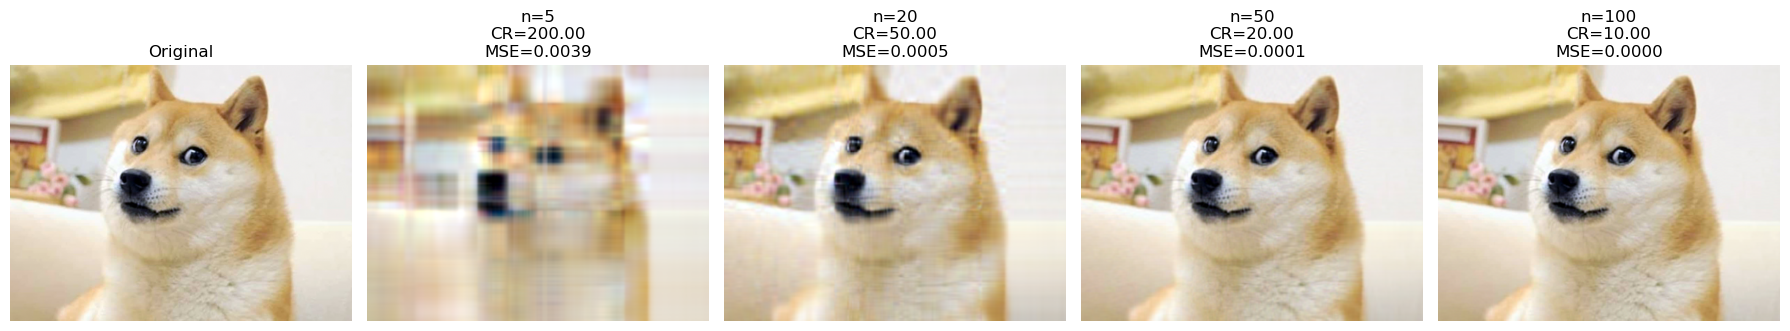

In [27]:
compress_image(image)

### Output Interpretation
n = 5 -> strong compression, blurry image

n = 20 -> moderate quality

n = 50 -> good balance

n = 100 -> near-original quality